# 20 - Efficiency (RQ3)

Parameter count, on-disk size and CPU inference latency. None of this needs a trained
checkpoint, so it can be run at any point.

Latency is measured on CPU on purpose. The deployment scenario the thesis argues about
is an offline phone app, and nobody is carrying an A40 around. EfficientNet-B3 is timed
at both 224 and 300 because latency scales with input area.

One caveat worth taking seriously: on a shared or virtualised host these timings are
noisy. In the earlier round the standard deviations came out at roughly half the mean,
which is too wide to defend. Pin the thread count and, if the numbers still look
unstable, re-run this part on a quiet local machine and use those figures instead.

In [1]:
import json, sys, time
from pathlib import Path

# Works whether the kernel starts in notebooks/ or at the repo root.
ROOT = Path.cwd()
while not (ROOT / "src" / "ham10000").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

DATA = ROOT / "data"
RUNS = ROOT / "runs"
print("repo:", ROOT)

repo: /workspace/ham10000-cnn-comparison


In [2]:
import subprocess
print(subprocess.run([sys.executable, str(ROOT / "scripts" / "benchmark_efficiency.py"),
                      "--threads", "1"],
                     capture_output=True, text=True).stdout)

Host      x86_64
Threads   1
Torch     2.8.0+cu128

mobilenet_v2       @224    2,232,839 params     9.07 MB     19.5 +/- 1.0 ms
resnet50           @224   23,522,375 params    94.30 MB    133.2 +/- 1.5 ms
efficientnet_b3    @224   10,706,991 params    43.18 MB     66.9 +/- 0.7 ms
efficientnet_b3    @300   10,706,991 params    43.18 MB    116.4 +/- 2.8 ms

Wrote /workspace/ham10000-cnn-comparison/runs/efficiency.json



In [3]:
import pandas as pd
eff = pd.DataFrame(json.loads((RUNS / "efficiency.json").read_text())["results"])
eff["params_M"] = (eff.trainable_params / 1e6).round(2)
print(eff[["architecture", "image_size", "params_M", "state_dict_mb",
           "cpu_latency_ms_mean", "cpu_latency_ms_std"]])

      architecture  image_size  params_M  state_dict_mb  cpu_latency_ms_mean  \
0     mobilenet_v2         224      2.23          9.068               19.483   
1         resnet50         224     23.52         94.302              133.224   
2  efficientnet_b3         224     10.71         43.178               66.932   
3  efficientnet_b3         300     10.71         43.178              116.358   

   cpu_latency_ms_std  
0               1.024  
1               1.542  
2               0.683  
3               2.755  


### Ratios against MobileNetV2

In [4]:
base = eff[(eff.architecture == "mobilenet_v2")].iloc[0]
for _, r in eff.iterrows():
    print(f"{r.architecture:<18} @{r.image_size}  "
          f"{r.trainable_params/base.trainable_params:>5.1f}x params  "
          f"{r.state_dict_mb/base.state_dict_mb:>5.1f}x size  "
          f"{r.cpu_latency_ms_mean/base.cpu_latency_ms_mean:>5.1f}x latency")

mobilenet_v2       @224    1.0x params    1.0x size    1.0x latency
resnet50           @224   10.5x params   10.4x size    6.8x latency
efficientnet_b3    @224    4.8x params    4.8x size    3.4x latency
efficientnet_b3    @300    4.8x params    4.8x size    6.0x latency


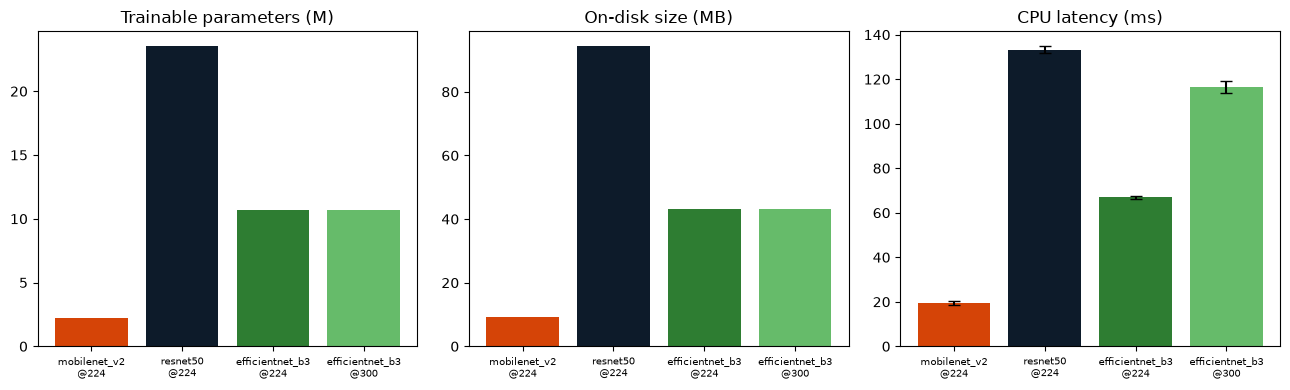

In [5]:
import matplotlib.pyplot as plt

labels = [f"{r.architecture}\n@{r.image_size}" for _, r in eff.iterrows()]
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col, title in [(axes[0], "params_M", "Trainable parameters (M)"),
                       (axes[1], "state_dict_mb", "On-disk size (MB)"),
                       (axes[2], "cpu_latency_ms_mean", "CPU latency (ms)")]:
    ax.bar(labels, eff[col], color=["#D54407", "#0D1B2A", "#2E7D32", "#66BB6A"])
    ax.set_title(title)
    ax.tick_params(axis="x", labelsize=7)
    if col == "cpu_latency_ms_mean":
        ax.errorbar(labels, eff[col], yerr=eff.cpu_latency_ms_std, fmt="none",
                    ecolor="black", capsize=4)
plt.tight_layout()
plt.show()